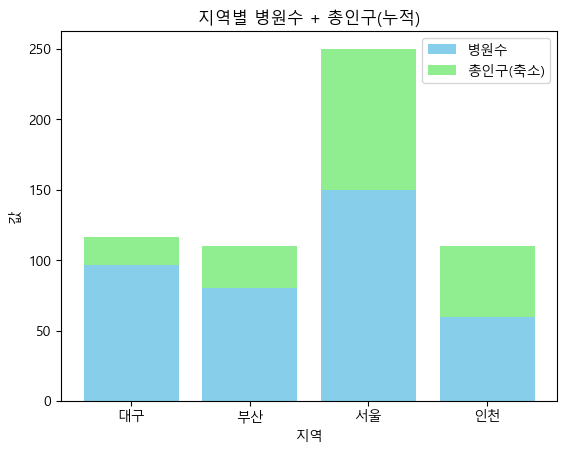

In [11]:
import pandas as pd
# matplotlib : 메트플롯 반드시 import 한다
import matplotlib.pyplot as plt
# 숫자 계산을 쉽게 하기 위한 라이브러리
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수
from scipy.interpolate import make_interp_spline

# 데이터 생성
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})
df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 데이터 전처리를 위해 merge
# outer 로 병합하면 df1과 df2가 합집합된다
merged = pd.merge(df1, df2, on="지역", how= "outer")
# merged

# 결측치 처리
# 결측치는 병원수와 총인구의 평균으로 정의한다
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
merged

# -------------------------------------------

# 가로 막대 그래프 만들기 : plt.bar
# x축 : 지역 / y축 : 병원수

# 반드시 한글 깨짐현상 코드를 삽입한다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 첫 번째 막대
plt.bar(merged['지역'], merged['병원수'], label='병원수', color='skyblue')

# 두 번째 막대
# 기존막대(=첫 번째 막대)위에 쌓는다
plt.bar(merged['지역'], merged['총인구']/10000, bottom=merged['병원수'], label='총인구(축소)', color='lightgreen')

plt.title('지역별 병원수 + 총인구(누적)')
plt.xlabel('지역')
plt.ylabel('값')

# 범례 표시
plt.legend()

plt.show()